# Community Variables & Strong/Weak Analysis 






In [3]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Riproducibilità
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

pd.set_option('display.float_format', '{:.4f}'.format)


---
## Caricamento e panoramica della rete




In [18]:
G = nx.read_graphml(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")

N = G.number_of_nodes()
E = G.number_of_edges()
print(f"Nodi        : {N:,}")
print(f"Archi       : {E:,}")
print(f"Densità globale: {nx.density(G):.6f}")
print()

group_attr = nx.get_node_attributes(G, 'group')
hier_attr  = nx.get_node_attributes(G, 'hierarchy')

gc = Counter(group_attr.values())
hc = Counter(hier_attr.values())
print("Dimensioni comunità:")
for k in sorted(gc): print(f"  {k}: {gc[k]:,} nodi")
print()
print("Dimensioni sotto-gruppi:")
for k in sorted(hc): print(f"  {k}: {hc[k]:,} nodi")


Nodi        : 16,639
Archi       : 50,605
Densità globale: 0.000366

Dimensioni comunità:
  A: 7,409 nodi
  B: 9,230 nodi

Dimensioni sotto-gruppi:
  A_CORE: 362 nodi
  A_PERIPHERY: 7,047 nodi
  B_CORE: 458 nodi
  B_PERIPHERY: 8,772 nodi


---
## Variabili di comunità 


In [7]:
def internal_external_degree(G, v, community):
    """Restituisce (k_int, k_ext) per il nodo v rispetto a 'community'."""
    C    = set(community) - {v}
    nbrs = set(G.neighbors(v)) - {v}
    return len(nbrs & C), len(nbrs - C)

def community_degree(G, community):
    """Somma dei gradi TOTALI dei nodi in community (k_C)."""
    return sum(dict(G.degree(community)).values())

def internal_link_density(G, community):
    """δ_int = 2*L_C / (N_C*(N_C-1))."""
    H = G.subgraph(community)
    n = H.number_of_nodes()
    if n < 2:
        return 0.0
    return 2 * H.number_of_edges() / (n * (n - 1))


In [8]:
C_A = [n for n, v in group_attr.items() if v == 'A']
C_B = [n for n, v in group_attr.items() if v == 'B']
partition_AB = [C_A, C_B]

summary_rows = []
for name, C in [('A', C_A), ('B', C_B)]:
    H      = G.subgraph(C)
    L_C    = H.number_of_edges()
    N_C    = len(C)
    k_C    = community_degree(G, C)
    delta  = internal_link_density(G, C)
    kin_v  = [internal_external_degree(G, v, C)[0] for v in C]
    kout_v = [internal_external_degree(G, v, C)[1] for v in C]
    summary_rows.append({
        'Comunità'       : name,
        '|C| (nodi)'     : N_C,
        'L_C (archi int)': L_C,
        'k_C (com.deg)'  : k_C,
        'δ_int'          : round(delta, 6),
        'mean k_int'     : round(np.mean(kin_v),  3),
        'mean k_ext'     : round(np.mean(kout_v), 3),
        'Σk_int'         : int(sum(kin_v)),
        'Σk_ext'         : int(sum(kout_v)),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)


,Comunità,|C| (nodi),L_C (archi int),k_C (com.deg),δ_int,mean k_int,mean k_ext,Σk_int,Σk_ext
0,A,7409,28384,61502,0.0010,7.6620,0.6390,56768,4734
1,B,9230,17487,39708,0.0004,3.7890,0.5130,34974,4734



Campionamo 500 sottoinsiemi casuali della stessa dimensione e confrontiamo la densità interna
osservata con quella attesa per caso.

In [21]:
nodes_all = list(G.nodes())

baseline_rows = []
for name, C in [('A', C_A), ('B', C_B)]:
    observed = internal_link_density(G, C)
    baseline = [
        internal_link_density(G, rng.choice(nodes_all, size=len(C), replace=False).tolist())
        for _ in range(500)
    ]
    z = (observed - np.mean(baseline)) / np.std(baseline)
    baseline_rows.append({
        'Comunità'           : name,
        'δ_int osservata'    : round(observed, 8),
        'δ_int random mean'  : round(float(np.mean(baseline)), 6),
        'z-score'            : round(z, 2),
    })

display(pd.DataFrame(baseline_rows))
print(f'δ_int osservata: {round(observed, 8)}')
#Interpretazione: z-score >> 1.96 → la densità interna è significativamente più alta di quella attesa per un sottoinsieme casuale della stessa dimensione.


,Comunità,δ_int osservata,δ_int random mean,z-score
0,A,0.0010,0.0004,25.7200
1,B,0.0004,0.0004,2.1700


δ_int osservata: 0.00041057


### Distribuzioni di k_int e k_ext per ogni comunità

Comunità A: mean k_int = 7.66,  mean k_ext = 0.64
Comunità B: mean k_int = 3.79,  mean k_ext = 0.51


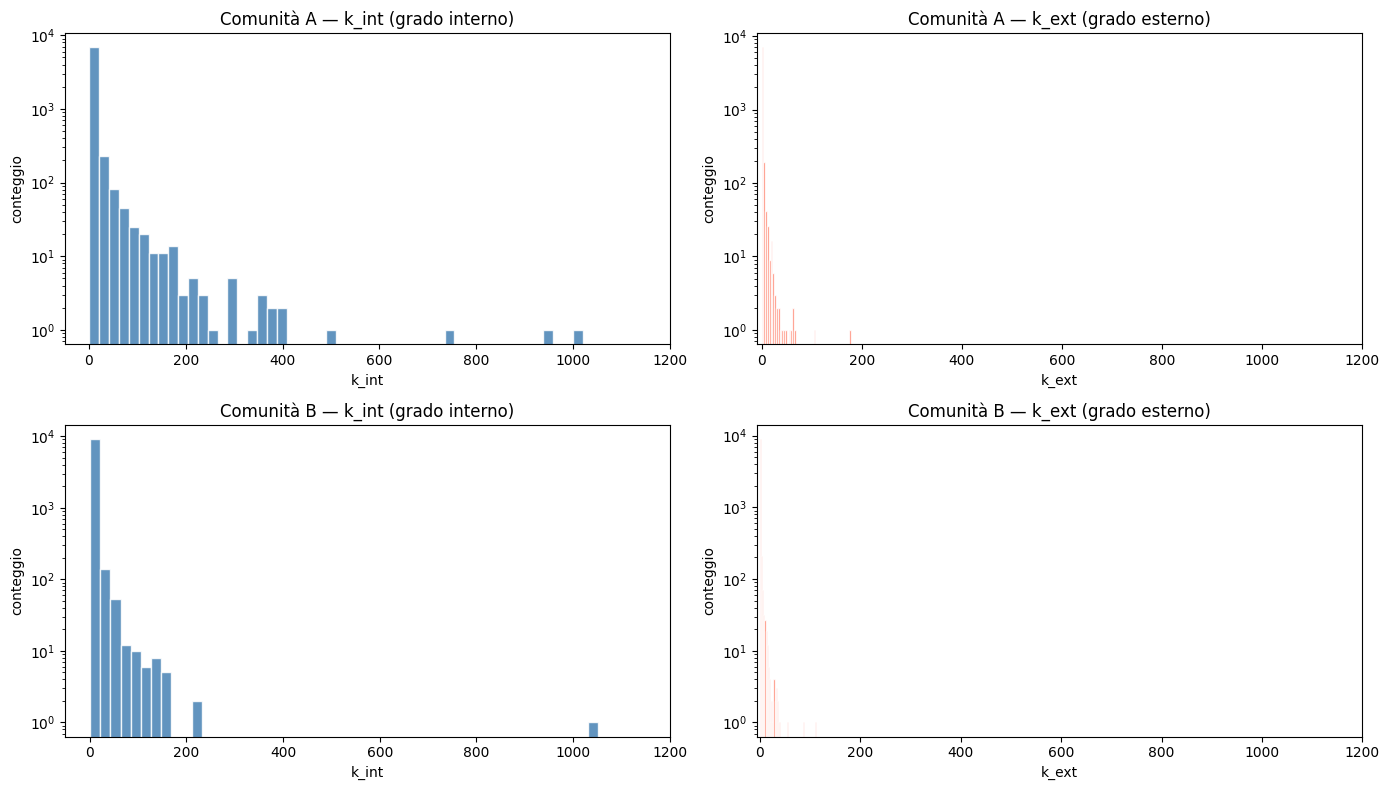

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (name, C) in enumerate([('A', C_A), ('B', C_B)]):
    kin_v  = [internal_external_degree(G, v, C)[0] for v in C]
    kout_v = [internal_external_degree(G, v, C)[1] for v in C]

    ax0 = axes[row_idx][0]
    ax1 = axes[row_idx][1]

    ax0.hist(kin_v,  bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax0.set_title(f"Comunità {name} — k_int (grado interno)")
    ax0.set_xlabel("k_int");  ax0.set_ylabel("conteggio")
    ax0.set_yscale('log')
    ax0.set_xlim(right=1200)


    ax1.hist(kout_v, bins=50, color='tomato', edgecolor='white', alpha=0.85)
    ax1.set_title(f"Comunità {name} — k_ext (grado esterno)")
    ax1.set_xlabel("k_ext");  ax1.set_ylabel("conteggio")
    ax1.set_yscale('log')
    ax1.set_xlim(right=1200)

    print(f"Comunità {name}: mean k_int = {np.mean(kin_v):.2f},  mean k_ext = {np.mean(kout_v):.2f}")

plt.tight_layout()
plt.show()


---
## Strong vs Weak Communities

Testiamo le quattro definizioni su due livelli di partizione:
1. Partizione primaria **A / B**
2. Partizione estesa **A_CORE / A_PERIPHERY / B_CORE / B_PERIPHERY**




In [23]:
def is_strong_community(G, community):
    """Strong (stringent): ogni nodo ha k_int > k_ext."""
    C = set(community)
    return all(
        internal_external_degree(G, v, C)[0] > internal_external_degree(G, v, C)[1]
        for v in C
    )

def is_weak_community(G, community):
    """Weak (stringent): Σk_int > Σk_ext."""
    C     = set(community)
    kin   = sum(internal_external_degree(G, v, C)[0] for v in C)
    kout  = sum(internal_external_degree(G, v, C)[1] for v in C)
    return kin > kout

def is_strong_less_stringent(G, community, partition):
    """Strong (less-stringent): per ogni v, k_int > k_v^D per ogni altra comunità D."""
    C      = set(community)
    others = [set(D) for D in partition if set(D) != C]
    for v in C:
        kin     = len(set(G.neighbors(v)) & (C - {v}))
        max_oth = max((len(set(G.neighbors(v)) & D) for D in others), default=0)
        if kin <= max_oth:
            return False
    return True

def is_weak_less_stringent(G, community, partition):
    """Weak (less-stringent): Σk_int > Σk_v^D per ogni altra comunità D."""
    C       = set(community)
    others  = [set(D) for D in partition if set(D) != C]
    kin_sum = sum(len(set(G.neighbors(v)) & (C - {v})) for v in C)
    if not others:
        return True
    max_oth = max(sum(len(set(G.neighbors(v)) & D) for v in C) for D in others)
    return kin_sum > max_oth

def fraction_violating_strong(G, community):
    """Frazione di nodi che violano il criterio strong stringente (k_int <= k_ext)."""
    C = list(community)
    viol = sum(1 for v in C
               if internal_external_degree(G, v, C)[0] <= internal_external_degree(G, v, C)[1])
    return viol, len(C), round(viol / len(C), 4)


### Test su partizione A / B

In [13]:
rows = []
for name, C in [('A', C_A), ('B', C_B)]:
    viol, tot, frac = fraction_violating_strong(G, C)
    kin_sum  = sum(internal_external_degree(G, v, C)[0] for v in C)
    kout_sum = sum(internal_external_degree(G, v, C)[1] for v in C)
    rows.append({
        'Comunità'               : name,
        'strong (stringent)'     : is_strong_community(G, C),
        'weak (stringent)'       : is_weak_community(G, C),
        'strong (less str.)'     : is_strong_less_stringent(G, C, partition_AB),
        'weak (less str.)'       : is_weak_less_stringent(G, C, partition_AB),
        'Σk_int'                 : kin_sum,
        'Σk_ext'                 : kout_sum,
        'Σk_int/Σk_ext ratio'    : round(kin_sum / kout_sum, 2),
        'nodi violano strong'    : viol,
        'fraz. violatori'        : frac,
    })

display(pd.DataFrame(rows).T)


,0,1
Comunità,A,B
strong (stringent),False,False
weak (stringent),True,True
strong (less str.),False,False
weak (less str.),True,True
Σk_int,56768,34974
Σk_ext,4734,4734
Σk_int/Σk_ext ratio,11.9900,7.3900
nodi violano strong,2,663
fraz. violatori,0.0003,0.0718


### Analisi per nodo — violatori del criterio strong (partizione A/B)

In [14]:
for name, C in [('A', C_A), ('B', C_B)]:
    print(f"=== Comunità {name} ===")
    hier_local = {v: hier_attr.get(v, '?') for v in C}
    viol_rows = []
    for v in C:
        kin, kext = internal_external_degree(G, v, C)
        if kin <= kext:
            viol_rows.append({'nodo': v, 'k_int': kin, 'k_ext': kext,
                               'hierarchy': hier_local[v]})
    df_viol = pd.DataFrame(viol_rows)
    print(f"  Violatori totali: {len(df_viol)} / {len(C)} ({100*len(df_viol)/len(C):.1f}%)")
    if not df_viol.empty:
        print("  Distribuzione per sotto-gruppo:")
        display(df_viol['hierarchy'].value_counts().to_frame())
    print()


=== Comunità A ===
  Violatori totali: 2 / 7409 (0.0%)
  Distribuzione per sotto-gruppo:


,count
hierarchy,
A_PERIPHERY,2



=== Comunità B ===
  Violatori totali: 663 / 9230 (7.2%)
  Distribuzione per sotto-gruppo:


,count
hierarchy,
B_PERIPHERY,660
B_CORE,3


### Test su partizione estesa CORE / PERIPHERY  (non credo abbia molto senso)



In [15]:
sub_communities = {}
for label in ['A_CORE', 'A_PERIPHERY', 'B_CORE', 'B_PERIPHERY']:
    sub_communities[label] = [n for n, v in hier_attr.items() if v == label]

partition_4 = list(sub_communities.values())

rows = []
for label, C in sub_communities.items():
    kin_sum  = sum(internal_external_degree(G, v, C)[0] for v in C)
    kout_sum = sum(internal_external_degree(G, v, C)[1] for v in C)
    viol, tot, frac = fraction_violating_strong(G, C)
    rows.append({
        'Sottocomunità'          : label,
        '|C|'                    : len(C),
        'δ_int'                  : round(internal_link_density(G, C), 6),
        'mean k_int'             : round(kin_sum / len(C), 3),
        'mean k_ext'             : round(kout_sum / len(C), 3),
        'strong (stringent)'     : is_strong_community(G, C),
        'weak (stringent)'       : is_weak_community(G, C),
        'strong (less str.)'     : is_strong_less_stringent(G, C, partition_4),
        'weak (less str.)'       : is_weak_less_stringent(G, C, partition_4),
        'fraz. violatori strong' : frac,
    })

display(pd.DataFrame(rows))


,Sottocomunità,|C|,δ_int,mean k_int,mean k_ext,strong (stringent),weak (stringent),strong (less str.),weak (less str.),fraz. violatori strong
0,A_CORE,362,0.1106,39.9390,55.3870,False,False,False,False,0.5276
1,A_PERIPHERY,7047,0.0002,1.0640,2.7660,False,False,False,False,0.8108
2,B_CORE,458,0.0255,11.6550,29.8190,False,False,False,False,0.7686
3,B_PERIPHERY,8772,0.0001,0.7940,1.5670,False,False,False,False,0.7666


### Riepilogo visivo — rapporti k_int / k_ext

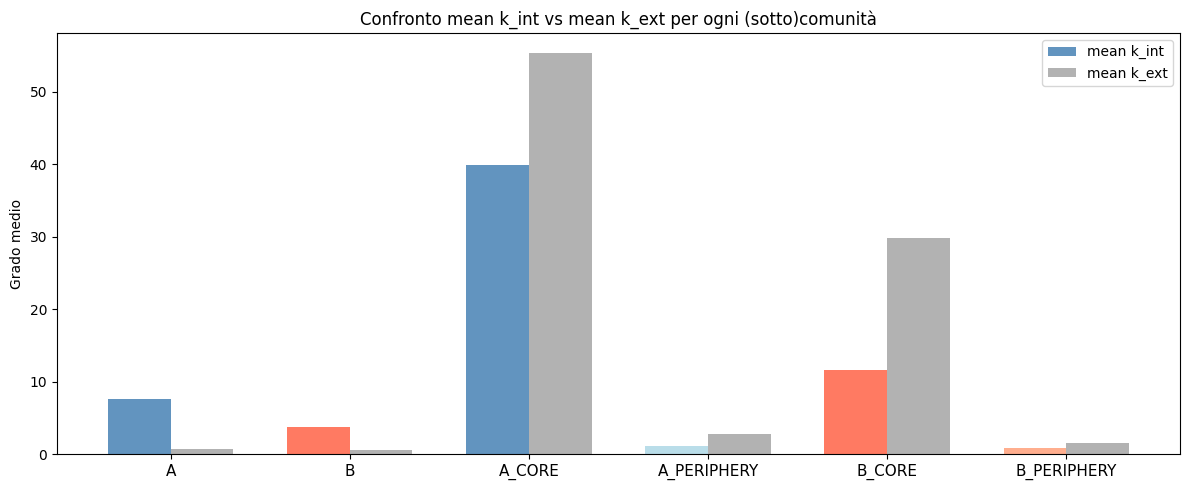

Ratio k_int / k_ext:
  A              : 7.662 / 0.639 = 11.99x
  B              : 3.789 / 0.513 = 7.39x
  A_CORE         : 39.939 / 55.387 = 0.72x
  A_PERIPHERY    : 1.064 / 2.766 = 0.38x
  B_CORE         : 11.655 / 29.819 = 0.39x
  B_PERIPHERY    : 0.794 / 1.567 = 0.51x


In [16]:
labels   = ['A', 'B', 'A_CORE', 'A_PERIPHERY', 'B_CORE', 'B_PERIPHERY']
all_C    = [C_A, C_B] + list(sub_communities.values())
colors   = ['steelblue','tomato','steelblue','lightblue','tomato','lightsalmon']

mean_kin  = []
mean_kext = []
for C in all_C:
    kin_v  = [internal_external_degree(G, v, C)[0] for v in C]
    kext_v = [internal_external_degree(G, v, C)[1] for v in C]
    mean_kin.append(np.mean(kin_v))
    mean_kext.append(np.mean(kext_v))

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, mean_kin,  w, label='mean k_int', color=colors, alpha=0.85)
ax.bar(x + w/2, mean_kext, w, label='mean k_ext', color='grey', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Grado medio')
ax.set_title('Confronto mean k_int vs mean k_ext per ogni (sotto)comunità')
ax.legend()
plt.tight_layout()
plt.show()

print("Ratio k_int / k_ext:")
for lbl, ki, ke in zip(labels, mean_kin, mean_kext):
    ratio = ki/ke if ke > 0 else float('inf')
    print(f"  {lbl:15s}: {ki:.3f} / {ke:.3f} = {ratio:.2f}x")


---
## Interpretazione dei risultati


#### Densità interna δ_int — bassa, ma non per caso
Le due comunità hanno densità interna **molto bassa** (A ≈ 0.001, B ≈ 0.0004), ovvero lontana da 1, è normale per reti di grandi dimensioni: la densità scala come O(1/N) in reti sparse, quindi confrontarla con 1 non ha senso. 
Il confronto corretto è con la **baseline random**: lo z-score indica di quante deviazioni standard la densità osservata supera quella attesa per caso (z-score > 10 la comunità sono molto coese rispetto alla struttura casuale)


#### k_int >> k_ext — separazione solida
In entrambe le comunità la media di k_int è molto maggiore di k_ext:
- Comunità A: ≈12x più vicini interni che esterni
- Comunità B: ≈7x

Questo indica che il flusso di retweet è prevalentemente **intra-comunità**: gli utenti ritwittano
principalmente altri utenti della stessa "bolla" informativa.

#### Strong (stringent) = False — normale su reti reali
Nessuna delle due comunità è *strong* in senso stringente: ci sono nodi periferici con
più vicini all'esterno che all'interno. Questo è atteso su reti reali e non invalida
la struttura comunitaria.

#### Weak (stringent) = True — struttura comunitaria confermata
Entrambe le comunità sono *deboli* nel senso stringente: la somma dei gradi interni
supera quella dei gradi esterni. Questo è il minimo indispensabile per parlare di comunità.

#### Less-stringent: il test più informativo
Il criterio less-stringent (che confronta ogni comunità contro la **singola** alternativa più
attraente, non contro tutto il resto) è quello più usato in pratica. Se entrambi i valori
sono True, la struttura comunitaria è robusta.

### CORE vs PERIPHERY 
La distinzione core/periphery rivela la struttura interna di ogni comunità:
- I **CORE** hanno mediamente più vicini interni dei **PERIPHERY** → sono gli utenti più
  integrati nella bolla
- I **PERIPHERY** hanno più violatori del criterio strong stringente → sono gli utenti
  "di confine", potenzialmente esposti a entrambe le narrative


